<a href="https://colab.research.google.com/github/tanviengineer/ai-learning-journey/blob/main/nlp_sentimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

import nltk
from  nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [ ]:
nlp=spacy.load("en_core_web_sm")

file_path="/content/twitter_training.csv"
df=pd.read_csv(file_path,header=None)

df.columns=['Tweet_ID',"Entity","Sentiment","Text"]

print("First five recoreds")
print(df.head())

First five recoreds
   Tweet_ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("Dataset information:")
print(df.info())

print("Missing values:")
print(df.isnull().sum())

print("Sentiment distribution:")
print(df['Sentiment'].value_counts())

Dataset Shape:
(74682, 4)
Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Tweet_ID   74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None
Missing values:
Tweet_ID       0
Entity         0
Sentiment      0
Text         686
dtype: int64
Sentiment distribution:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64


In [ ]:
df=df.dropna(subset=['Text','Sentiment'])
print("Dataset shape after removing missing values:")
print(df.shape)

Dataset shape after removing missing values:
(73996, 4)


In [ ]:
df=df[df["Sentiment"].isin(['Positive','Negative','Neutral'])]
print("Sentiment distribution after removing Irrelevant:")
print(df['Sentiment'].value_counts())

Sentiment distribution after removing Irrelevant:
Sentiment
Negative    22358
Positive    20655
Neutral     18108
Name: count, dtype: int64


In [ ]:
stop_words=stopwords.words("english")
lemmatizer=WordNetLemmatizer()

def clean_text(text):
  text=str(text)
  #convert to lower
  text=text.lower()
  #remove url
  text=re.sub(r"http\S+/www\S+","",text)
  #remove mentions
  text=re.sub(r"@","",text)
  #removing hashing symbols but keep the word
  text=re.sub(r"#","",text)
  #remove no.s
  text=re.sub(r"\d+","",text)
  text=re.sub(r"\s+","",text).strip()
  words=text.split() # tokenization

  #remove stopwords
  words=[word for word in words if word not in stop_words]

  #Lemmatizing using nltk
  words=[lemmatizer.lemmatize(word) for word in words ]

  return"".join(words)


df['Clean_text']=df['Text'].apply(clean_text)

print("Original and cleaned text:")
print(df[["Text","Clean_text"]].head(10))

#remove empty text records
df=df[df['Clean_text'].str.strip()!=""]

Original and cleaned text:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                          Clean_text  
0        imgettingonborderlandsandiwillmurderyouall,  
1           iamcomingtothebordersandiwillkillyouall,  
2          imgettingonborderlandsandiwillkillyouall,  
3         imcomingonborderlandsandiwillmurderyouall,  
4      imgettingonborderlandsandiwillmurderyoumeall,  
5       imgettingintoborde

In [ ]:
#optional spacy preprocessing

def spacy_preprocess(text):
  doc=nlp(text)
  tokens=[]

  for token in doc:
    if(not token.is_stop and not token.is_punct and not token.is_space ):
      tokens.append(token.lemma_.lower())
  return " ".join(tokens)

#apply spacy preprocessing

df['Processed_Text']=df['Clean_text'].apply(spacy_preprocess)
print("Text after spacy preprocessing:")
print(df[["Text","Processed_Text"]].head(10))

X=df["Processed_Text"]
y=df["Sentiment"]



Text after spacy preprocessing:
                                                Text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   
5  im getting into borderlands and i can murder y...   
6  So I spent a few hours making something for fu...   
7  So I spent a couple of hours doing something f...   
8  So I spent a few hours doing something for fun...   
9  So I spent a few hours making something for fu...   

                                      Processed_Text  
0         imgettingonborderlandsandiwillmurderyouall  
1            iamcomingtothebordersandiwillkillyouall  
2           imgettingonborderlandsandiwillkillyouall  
3          imcomingonborderlandsandiwillmurderyouall  
4       imgettingonborderlandsandiwillmurderyoumeall  
5        imgettingint

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=23,stratify=y)

print("Training Samples:",len(X_train))
print("Testing samples:",len(X_test))
vectorizer=TfidfVectorizer()
X_train_tfidf=vectorizer.fit_transform(X_train)
X_test_tfidf=vectorizer.transform(X_test)

print("TFidf Training shape:",X_train_tfidf.shape)
print("Tfidf Testing shpae:",X_test_tfidf.shape)

Training Samples: 47991
Testing samples: 11998
TFidf Training shape: (47991, 97800)
Tfidf Testing shpae: (11998, 97800)


In [ ]:


model=MultinomialNB()

model.fit(X_train_tfidf,y_train)
print("Model training completed successfully")





Model training completed successfully


Accuracy:0.7626
Precision:0.8061
Recall:0.7626
F1-score:0.7617
Classification Report:
              precision    recall  f1-score   support

    Negative       0.64      0.94      0.76      4400
     Neutral       0.89      0.73      0.80      3547
    Positive       0.91      0.61      0.73      4051

    accuracy                           0.76     11998
   macro avg       0.81      0.76      0.76     11998
weighted avg       0.81      0.76      0.76     11998

Confusion Matrix: [[2457 1430  164]
 [ 127 4115  158]
 [ 114  855 2578]]


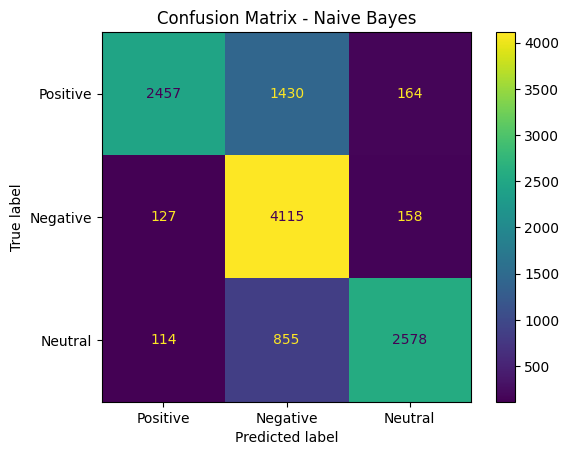

In [ ]:
y_pred=model.predict(X_test_tfidf)

accuracy=accuracy_score(y_test,y_pred)

print(f"Accuracy:{accuracy:.4f}")


precision=precision_score(y_test,y_pred,average='weighted')
print(f"Precision:{precision:.4f}")

recall=recall_score(y_test,y_pred,average='weighted')
print(f"Recall:{recall:.4f}")

f1=f1_score(y_test,y_pred,average='weighted')
print(f"F1-score:{f1:.4f}")

print("Classification Report:")
print(classification_report(y_test,y_pred))

cm=confusion_matrix(y_test,y_pred,labels=["Positive","Negative","Neutral"])
print("Confusion Matrix:",cm)


disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=["Positive","Negative","Neutral"])

disp.plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()



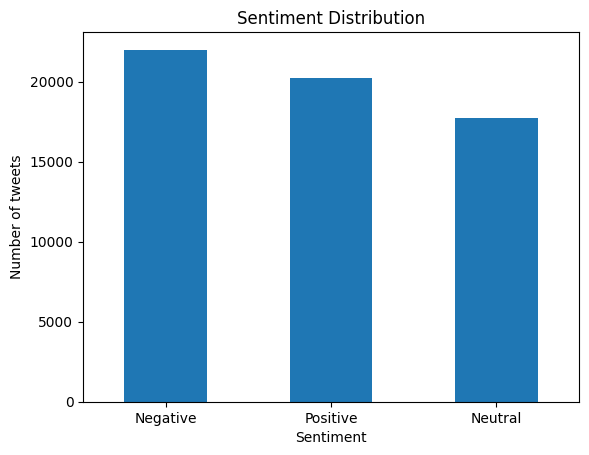

In [ ]:
df["Sentiment"].value_counts().plot(kind='bar')

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of tweets")
plt.xticks(rotation=0)
plt.show()



In [ ]:
#function to predict text

def predict_sentiment(text):
  cleaned=clean_text(text)

  processed=spacy_preprocess(cleaned)

  text_vector=vectorizer.transform([processed])

  prediction=model.predict(text_vector)[0]

  probabilities=model.predict_proba(text_vector)[0]

  print("Input Text")
  print(text)

  print("Predicted Sentiment:")
  print(prediction)

  print("Prediction Probabilities:")
  for label,probability in zip(model.classes_,probabilities):
    print(f"{label}:{probability:.4f}")


  return prediction


In [ ]:
predict_sentiment("I absolutely love this product, it is amazing!")
predict_sentiment("This is the worst experience I have ever had.")
predict_sentiment("This product was delivered today.")

new_sentences=["I really enjoyed this game.",
               "This is terrible and completely disappinting.",
               "The service was okay",
               "I am extremely happy with the purchase",
               "I don't like this product at all.",
               "This package arrived yesterday."]

print("Predictions for New Tweets:")
print("-" * 50)

for sentence in new_sentences:
  prediction=predict_sentiment(sentence)
  print("-"*50)





Input Text
I absolutely love this product, it is amazing!
Predicted Sentiment:
Negative
Prediction Probabilities:
Negative:0.3667
Neutral:0.2957
Positive:0.3376
Input Text
This is the worst experience I have ever had.
Predicted Sentiment:
Negative
Prediction Probabilities:
Negative:0.3667
Neutral:0.2957
Positive:0.3376
Input Text
This product was delivered today.
Predicted Sentiment:
Negative
Prediction Probabilities:
Negative:0.3667
Neutral:0.2957
Positive:0.3376
Predictions for New Tweets:
--------------------------------------------------
Input Text
I really enjoyed this game.
Predicted Sentiment:
Negative
Prediction Probabilities:
Negative:0.3667
Neutral:0.2957
Positive:0.3376
--------------------------------------------------
Input Text
This is terrible and completely disappinting.
Predicted Sentiment:
Negative
Prediction Probabilities:
Negative:0.3667
Neutral:0.2957
Positive:0.3376
--------------------------------------------------
Input Text
The service was okay
Predicted Sentim

In [ ]:

print("FINAL MODEL PERFORMANCE")
print("=====================================")
print(f"Accuracy:{accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1-Score:{f1:.4f}")




FINAL MODEL PERFORMANCE
Accuracy:0.7626
Precision:0.8061
Recall:0.7626
F1-Score:0.7617


In [ ]:

print("FINAL MODEL PERFORMANCE")
print("=======================================")

print(f"Accuracy:{accuracy:.4f}")
print(f"Precision:{precision:.4f}")
print(f"Recall:{recall:.4f}")
print(f"F1-Score:{f1:.4f}")




FINAL MODEL PERFORMANCE
Accuracy:0.7626
Precision:0.8061
Recall:0.7626
F1-Score:0.7617
